In [1]:
import ee
import os
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import START_DATE, END_DATE, extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
import numpy as np
import folium
import matplotlib.patches as mpatches

hpd.util.get_color_logger("INFO")
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 3
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 3/3 [00:22<00:00,  7.38s/it]


In [4]:
m = oc.plots.interactive_map(
    color="red",
    zoom_start=20,
    tiles="Esri.WorldImagery",
    popup_width=350
)

lon_min, lat_min, lon_max, lat_max = extent_to_ee("ndvi")

folium.Rectangle(
    bounds=[(lat_min, lon_min), (lat_max, lon_max)],  # folium gebruikt (lat, lon)
    fill=False,
    weight=3
).add_to(m)

m

In [5]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs,lat,lon
name,,,,,,,,,,,,,,,
GMW000000037950001,91148.862012,436904.950659,128567-945,,lizard,m NAP,1,-2.40,-4.40,-1.32,-1.40,True,GroundwaterObs GMW000000037950001 -----metadat...,51.916964,4.459105
GMW000000038215001,91090.571901,436889.230981,128566-846,,lizard,m NAP,1,-2.39,-3.39,-1.21,-1.29,True,GroundwaterObs GMW000000038215001 -----metadat...,51.916816,4.458261
GMW000000102269001,91100.992742,436914.046908,128567-57,,lizard,m NAP,1,-1.97,-2.97,-1.12,-1.12,True,GroundwaterObs GMW000000102269001 -----metadat...,51.917040,4.458408


In [6]:
gw = oc.obs["GMW000000037950001"]
print(gw)

GroundwaterObs GMW000000037950001
-----metadata------
name : GMW000000037950001 
x : 91148.86201235745 
y : 436904.95065888227 
location : 128567-945 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -2.4 
screen_bottom : -4.4 
ground_level : -1.32 
tube_top : -1.4 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2016-01-13 00:00:00  -2.59   NaN  Gemeten   hand
2016-02-11 00:00:00  -2.55   NaN  Gemeten   hand
2016-03-15 00:00:00  -2.66   NaN  Gemeten   hand
2016-04-11 23:00:00  -2.62   NaN  Gemeten   hand
2016-05-10 23:00:00  -2.64   NaN  Gemeten   hand
...                    ...   ...      ...    ...
2026-03-29 00:20:00  -2.81   2.0           diver
2026-03-29 00:30:00  -2.81   2.0           diver
2026-03-29 00:40:00  -2.80   2.0           diver
2026-03-29 00:50:00  -2.80   2.0           diver
2026-03-29 01:00:00  -2.80   2.0           diver

[9329 rows x 4 columns]

In [7]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2016-01-13 00:00:00 2026-03-29 01:00:00
(9328,)


In [8]:
ts_year = ts.loc[START_DATE:END_DATE]

ts_daily_raw = ts_year.resample("D").mean()

ts_daily = ts_daily_raw.interpolate(method="time")

is_interpolated = ts_daily_raw.isna()

In [41]:
percentile = 0.30 # Waarom 30

# === FIXED THRESHOLD ===
threshold_fixed = ts_daily.quantile(percentile)

# === VARIABLE THRESHOLD ===
monthly_threshold = (
    ts_daily
    .groupby(ts_daily.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))          # zorg dat alle maanden bestaan
)

n_months_with_data = monthly_threshold.notna().sum()

if n_months_with_data < 6:
    print(
        f"Not enough data for variable threshold ({n_months_with_data} months). "
        "Variable threshold will not be used."
    )
    threshold_variable_smooth = None
else:
    monthly_threshold = monthly_threshold.interpolate(method="linear")

    threshold_variable = ts_daily.index.to_series().map(
        lambda d: monthly_threshold.loc[d.month]
    )

    threshold_variable_smooth = (
        threshold_variable
        .rolling(window=20, min_periods=1)
        .mean()
    )

# === KIES welke threshold wordt gebruikt voor DROOGTE ===
threshold = threshold_variable_smooth if threshold_variable_smooth is not None else threshold_fixed


In [42]:
is_drought_fixed = ts_daily <= threshold_fixed

if threshold_variable_smooth is not None:
    is_drought_variable = ts_daily <= threshold_variable_smooth
else:
    is_drought_variable = None

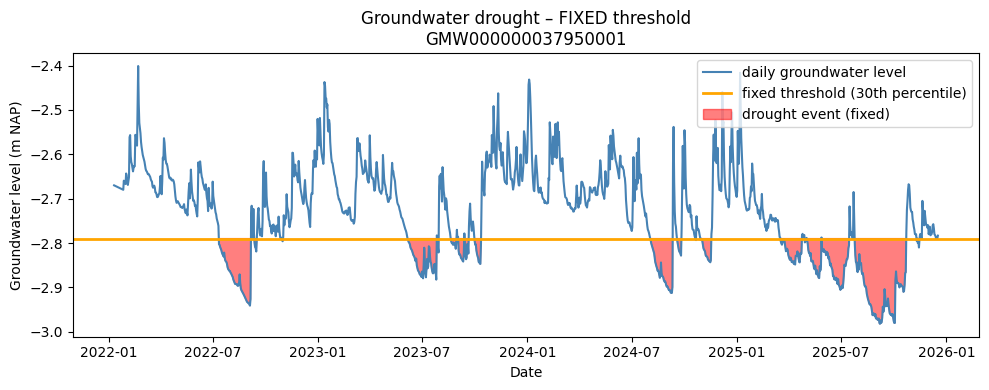

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

ax.axhline(
    threshold_fixed,
    color="orange",
    linewidth=2,
    linestyle="-",
    label="fixed threshold (30th percentile)",
)

ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold_fixed,
    where=is_drought_fixed,
    color="red",
    alpha=0.5,
    label="drought event (fixed)",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – FIXED threshold\n{gw.name}")
ax.legend()

plt.tight_layout()
plt.show()

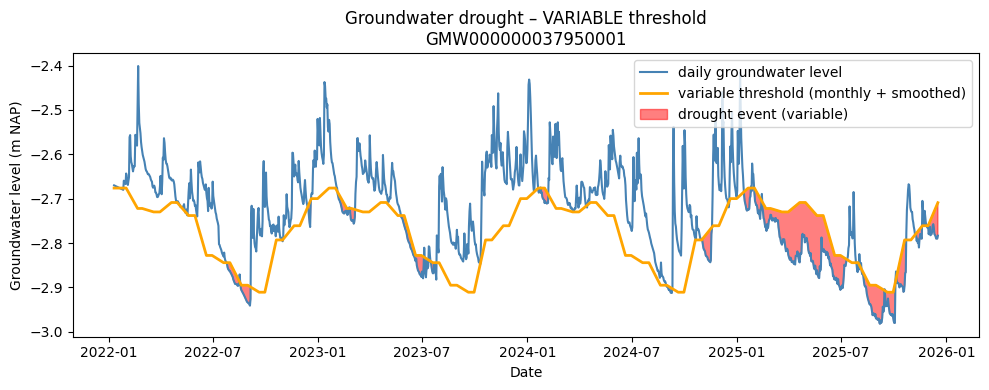

In [44]:
if threshold_variable_smooth is not None:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        ts_daily.index,
        ts_daily,
        color="steelblue",
        linewidth=1.5,
        label="daily groundwater level",
    )

    ax.plot(
        threshold_variable_smooth.index,
        threshold_variable_smooth.values,
        color="orange",
        linewidth=2,
        label="variable threshold (monthly + smoothed)",
    )

    ax.fill_between(
        ts_daily.index,
        ts_daily,
        threshold_variable_smooth,
        where=is_drought_variable,
        color="red",
        alpha=0.5,
        label="drought event (variable)",
        interpolate=True,
    )

    ax.set_ylabel("Groundwater level (m NAP)")
    ax.set_xlabel("Date")
    ax.set_title(f"Groundwater drought – VARIABLE threshold\n{gw.name}")
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Variable threshold plot skipped: insufficient data.")


In [45]:
# =========================
# SAMENVATTING – FIXED THRESHOLD
# =========================
duration_fixed = is_drought_fixed.sum()
max_deficit_fixed = (threshold_fixed - ts_daily[is_drought_fixed]).max()

n_interpolated = is_interpolated.sum()

print("=== FIXED THRESHOLD (30th percentile) ===")
print(
    f"Drought duration (2024–2025): {duration_fixed} days. "
    f"{n_interpolated} days were interpolated."
)
print(f"Maximum deficit (2024–2025): {max_deficit_fixed:.2f} m\n")


# =========================
# SAMENVATTING – VARIABLE THRESHOLD
# =========================
if is_drought_variable is not None:
    duration_variable = is_drought_variable.sum()
    max_deficit_variable = (
        threshold_variable_smooth - ts_daily[is_drought_variable]
    ).max()

    print("=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===")
    print(
        f"Drought duration (2024–2025): {duration_variable} days. "
        f"{n_interpolated} days were interpolated."
    )
    print(f"Maximum deficit (2024–2025): {max_deficit_variable:.2f} m\n")
else:
    print("=== VARIABLE THRESHOLD ===")
    print("Not enough data to compute variable threshold.\n")


# =========================
# DAGELIJKS OVERZICHT (WAARDES + HERKOMST)
# =========================
origin_per_day = (
    gw[["value", "origin"]]
    .dropna()
    .assign(date=lambda df: df.index.normalize())
    .groupby("date")["origin"]
    .agg(lambda x: ",".join(sorted(set(x))))
)

summary = pd.DataFrame({
    "value": ts_daily,
    "interpolated": is_interpolated,
})

summary["origin"] = origin_per_day
summary.loc[summary["interpolated"], "origin"] = "interpolated"

# Toon de volledige tabel (alle rijen en kolommen)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000):
    print(summary.to_string())



=== FIXED THRESHOLD (30th percentile) ===
Drought duration (2024–2025): 432 days. 20 days were interpolated.
Maximum deficit (2024–2025): 0.19 m

=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===
Drought duration (2024–2025): 477 days. 20 days were interpolated.
Maximum deficit (2024–2025): 0.14 m

                    value  interpolated                      origin
peil_datum_tijd                                                    
2022-01-10      -2.670000         False                        hand
2022-01-11      -2.670625          True                interpolated
2022-01-12      -2.671250          True                interpolated
2022-01-13      -2.671875          True                interpolated
2022-01-14      -2.672500          True                interpolated
2022-01-15      -2.673125          True                interpolated
2022-01-16      -2.673750          True                interpolated
2022-01-17      -2.674375          True                interpolated
2022-

In [46]:
# =========================
# COMPACTE & SNELLE EE INIT
# =========================

project = "afstuderen-481613"

try:
    ee.Initialize(project=project)
    print("Earth Engine initialized.")
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project)
    print("Earth Engine authenticated and initialized.")

roi = ee.Geometry.Rectangle(extent_to_ee("ndvi"))

Earth Engine initialized.


In [47]:
def mask_s2_clouds(img):
    scl = img.select("SCL")
    mask = (
        scl.neq(3)   # cloud shadow
        .And(scl.neq(7))
        .And(scl.neq(8))
        .And(scl.neq(9))   # clouds
        .And(scl.neq(10))
        .And(scl.neq(11))  # snow
    )
    return img.updateMask(mask)


def add_ndvi_s2(img):
    return img.addBands(
        img.normalizedDifference(["B8", "B4"]).rename("NDVI")
    )


def reduce_ndvi(img):
    stats = img.select("NDVI").reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.count(), None, True),
        geometry=roi,
        scale=10,
        bestEffort=True,
        maxPixels=1e13,
    )

    return ee.Feature(None, {
        "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
        "ndvi": stats.get("NDVI_mean"),
        "n_pixels": stats.get("NDVI_count"),
    })


col = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate(NDVI_START_DATE, NDVI_END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .map(mask_s2_clouds)
    .map(add_ndvi_s2)
)

fc = col.map(reduce_ndvi)
features = fc.getInfo()["features"]

rows = []
for f in features:
    p = f["properties"]
    if p["ndvi"] is not None and p["n_pixels"] is not None:
        rows.append(p)

df_s2 = pd.DataFrame(rows)
df_s2["date"] = pd.to_datetime(df_s2["date"])
df_s2 = df_s2.sort_values("date").reset_index(drop=True)

In [48]:
roi_area = roi.area().getInfo()
expected_pixels = roi_area / (10 * 10)
min_required = expected_pixels * 0.70

df_s2 = df_s2[df_s2["n_pixels"] >= min_required].reset_index(drop=True)

print("Remaining NDVI scenes:", len(df_s2))

Remaining NDVI scenes: 71


In [49]:
ndvi_ts = df_s2.set_index("date")["ndvi"]

ndvi_daily_raw = ndvi_ts.resample("D").mean()
ndvi_daily = ndvi_daily_raw.interpolate("time")

In [50]:
ndvi_threshold_fixed = ndvi_daily.quantile(0.30)
is_ndvi_stress = ndvi_daily <= ndvi_threshold_fixed

In [51]:
# Use only the NDVI values between NDVI_START_DATE and NDVI_END_DATE for the threshold
ndvi_threshold_fixed = ndvi_daily.loc[NDVI_START_DATE:NDVI_END_DATE].quantile(0.30)

  ndvi_fixed = is_ndvi_stress.reindex(common_index).fillna(False)

  gw_fixed = is_drought_fixed.reindex(common_index).fillna(False)



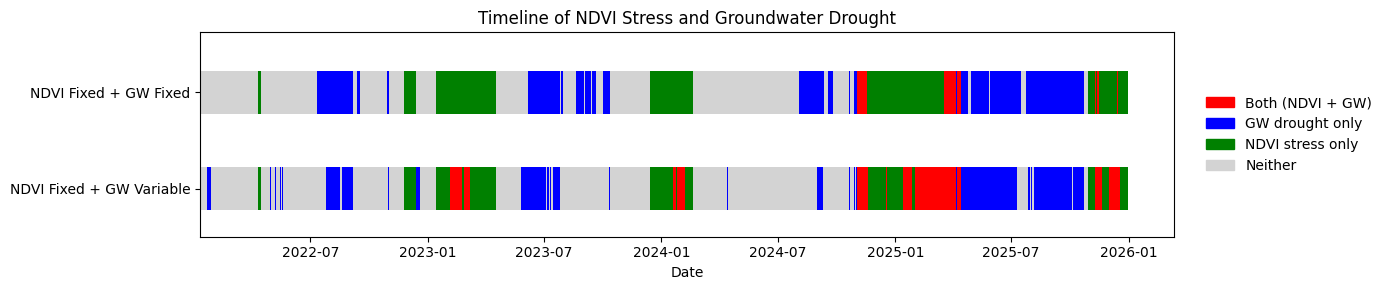

In [52]:
# =========================
# TWO TIMELINES: FIXED GW vs VARIABLE GW (both with fixed NDVI)
# =========================
# Fixed NDVI
# Build a common daily index that covers the available NDVI and groundwater ranges
# This makes the timeline code robust to different extents and date ranges.
indices = [i for i in [ts_daily.index, ndvi_daily.index] if len(i) > 0]
if len(indices) == 0:
    common_index = pd.DatetimeIndex([])
else:
    start = min(idx.min() for idx in indices)
    end = max(idx.max() for idx in indices)
    try:
        start_limit = pd.to_datetime(START_DATE)
        end_limit = pd.to_datetime(END_DATE)
        start = max(pd.to_datetime(start), start_limit)
        end = min(pd.to_datetime(end), end_limit)
    except Exception:
        pass
    common_index = pd.date_range(start=start.normalize(), end=end.normalize(), freq="D")
ndvi_fixed = is_ndvi_stress.reindex(common_index).fillna(False)
# Fixed groundwater
gw_fixed = is_drought_fixed.reindex(common_index).fillna(False)
# Variable groundwater
ts_daily_common = ts_daily.reindex(common_index)
monthly_threshold_gw = (
    ts_daily_common
    .groupby(ts_daily_common.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))
    .interpolate(method="linear")
)
threshold_variable_gw = ts_daily_common.index.to_series().map(
    lambda d: monthly_threshold_gw.loc[d.month]
)
threshold_variable_gw_smooth = (
    threshold_variable_gw
    .rolling(window=20, min_periods=1)
    .mean()
)
gw_variable = (ts_daily_common <= threshold_variable_gw_smooth).fillna(False)
# --- Combinaties voor Fixed GW + Fixed NDVI ---
both_fixed = ndvi_fixed & gw_fixed
ndvi_only_fixed = ndvi_fixed & ~gw_fixed
gw_only_fixed = gw_fixed & ~ndvi_fixed
neither_fixed = ~(ndvi_fixed | gw_fixed)
# --- Combinaties voor Variable GW + Fixed NDVI ---
both_var = ndvi_fixed & gw_variable
ndvi_only_var = ndvi_fixed & ~gw_variable
gw_only_var = gw_variable & ~ndvi_fixed
neither_var = ~(ndvi_fixed | gw_variable)
# Functie om segmenten te bouwen
def build_segments(both, gw_only, ndvi_only):
    timeline = pd.Series("neither", index=common_index)
    timeline[both] = "both"
    timeline[gw_only] = "gw_only"
    timeline[ndvi_only] = "ndvi_only"
    blocks = timeline.ne(timeline.shift()).cumsum()
    return timeline.groupby(blocks).agg(
        start=lambda x: x.index[0],
        end=lambda x: x.index[-1],
        category="first"
    )
colors = {
    "both": "red",
    "gw_only": "blue",
    "ndvi_only": "green",
    "neither": "lightgrey",
}
segments_fixed = build_segments(both_fixed, gw_only_fixed, ndvi_only_fixed)
segments_var = build_segments(both_var, gw_only_var, ndvi_only_var)
fig, ax = plt.subplots(figsize=(14, 3))
# Y-posities en bar-height
y_fixed = 0.6
y_var = 0.2
bar_height = 0.18
# Plot Fixed GW + Fixed NDVI
for _, row in segments_fixed.iterrows():
    ax.barh(
        y_fixed,
        (row["end"] - row["start"]).days + 1,
        left=row["start"],
        color=colors[row["category"]],
        height=bar_height
    )
# Plot Variable GW + Fixed NDVI
for _, row in segments_var.iterrows():
    ax.barh(
        y_var,
        (row["end"] - row["start"]).days + 1,
        left=row["start"],
        color=colors[row["category"]],
        height=bar_height
    )
ax.set_yticks([y_fixed, y_var])
ax.set_yticklabels([
    "NDVI Fixed + GW Fixed",
    "NDVI Fixed + GW Variable"
])
ax.set_ylim(0, 0.85)
ax.set_xlabel("Date")
ax.set_title("Timeline of NDVI Stress and Groundwater Drought")
# Legenda rechts buiten de plot
import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(color="red", label="Both (NDVI + GW)"),
    mpatches.Patch(color="blue", label="GW drought only"),
    mpatches.Patch(color="green", label="NDVI stress only"),
    mpatches.Patch(color="lightgrey", label="Neither"),
]
ax.legend(
    handles=legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()

Discussiepunten:
- 30e percentiel
- NDVI meetfrequentie na filtering

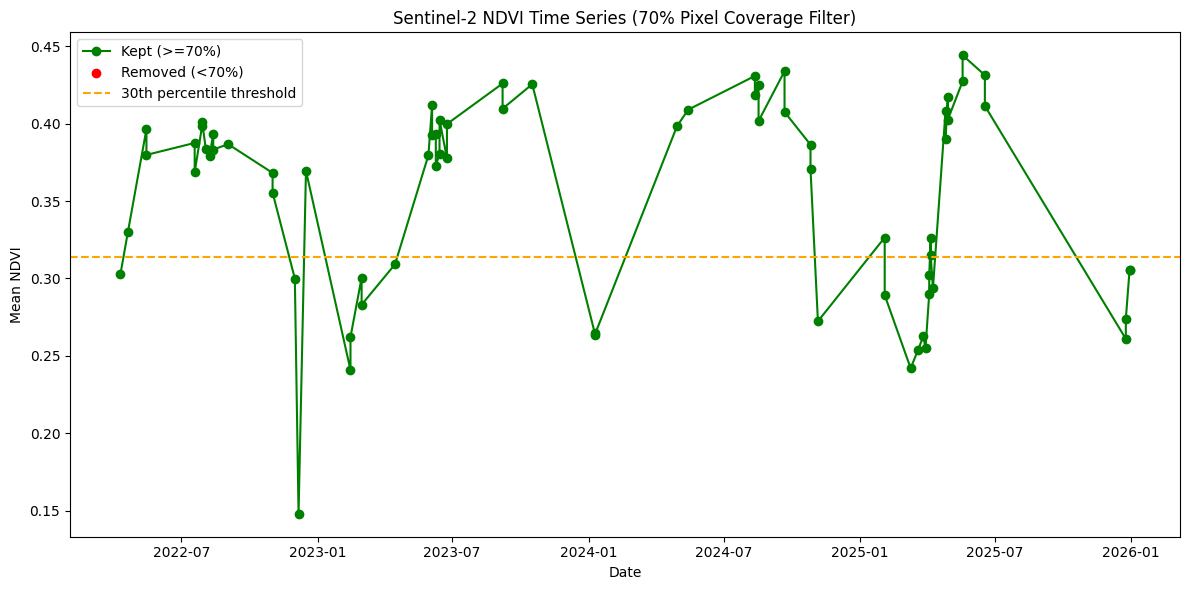

Aantal verwijderde punten: 0
Aantal behouden punten: 71


In [53]:
# Plot NDVI time series (filtered) with 30th percentile threshold and removed points
ndvi_filtered = ndvi_daily.loc[START_DATE:END_DATE]
df_s2_filtered = df_s2[(df_s2['date'] >= pd.to_datetime(START_DATE)) & (df_s2['date'] <= pd.to_datetime(END_DATE))]
removed = df_s2_filtered[df_s2_filtered['n_pixels'] < min_required]
kept = df_s2_filtered[df_s2_filtered['n_pixels'] >= min_required]
threshold_30 = ndvi_filtered.quantile(0.30)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(kept['date'], kept['ndvi'], 'o-', color='green', label='Kept (>=70%)')
ax.scatter(removed['date'], removed['ndvi'], color='red', label='Removed (<70%)')
ax.axhline(threshold_30, color='orange', linestyle='--', label='30th percentile threshold')
ax.set_ylabel('Mean NDVI')
ax.set_xlabel('Date')
ax.set_title('Sentinel-2 NDVI Time Series (70% Pixel Coverage Filter)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Aantal verwijderde punten: {len(removed)}")
print(f"Aantal behouden punten: {len(kept)}")

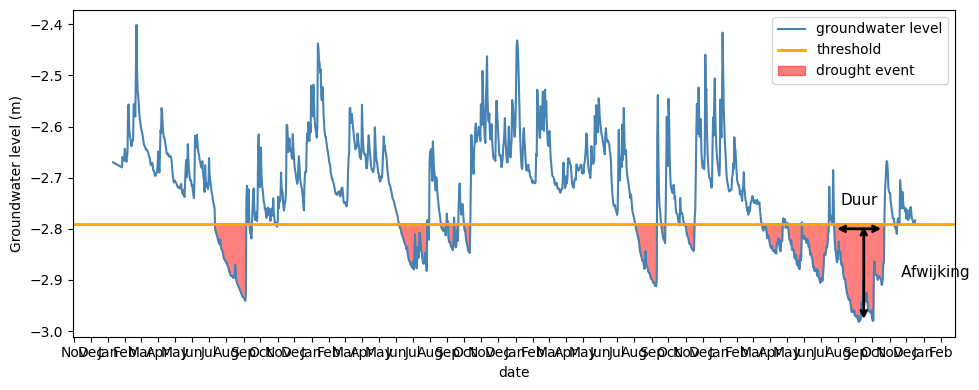

In [54]:
# Plot vaste threshold met aangepaste annotaties: duur boven het rode vlak, deficit-pijl en tekst verder naar rechts
import matplotlib.dates as mdates
from itertools import groupby
from operator import itemgetter
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 4))

# Plot grondwaterstand en threshold
ax.plot(ts_daily.index, ts_daily, color="steelblue", linewidth=1.5, label="groundwater level")
ax.axhline(threshold_fixed, color="orange", linewidth=2, linestyle="-", label="threshold")

# Rood vlak: droogte
ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold_fixed,
    where=is_drought_fixed,
    color="red",
    alpha=0.5,
    label="drought event",
    interpolate=True,
)

# Zoek het langste aaneengesloten droogte-interval
indices = is_drought_fixed[is_drought_fixed].index
intervals = []
for k, g in groupby(enumerate(indices), lambda ix: ix[0] - ix[1].toordinal()):
    group = list(map(itemgetter(1), g))
    intervals.append(group)
longest = max(intervals, key=len) if intervals else []

if longest:
    start, end = longest[0], longest[-1]
    # Horizontale pijl voor duur
    ax.annotate(
        '', xy=(end, threshold_fixed-0.01), xytext=(start, threshold_fixed-0.01),
        arrowprops=dict(arrowstyle='<->', color='black', lw=2)
    )
    # Tekst boven het rode vlak
    ax.text(
        start + (end-start)/2, threshold_fixed+0.03,
        'Duur', ha='center', va='bottom', fontsize=11, color='black'
    )
    # Maximale afwijking (diepte) - pijl verder naar rechts
    drought_vals = ts_daily[longest]
    min_idx = drought_vals.idxmin()
    min_val = drought_vals.min()
    # Zoek een tijdstip 10% verder naar rechts binnen het interval, of het einde
    right_idx = pd.to_datetime(min_idx) + (end-start)*0.10
    # Corrigeer als buiten bereik
    if right_idx > end:
        right_idx = end
    # Y-waarden voor pijl
    y0 = threshold_fixed
    y1 = min_val
    ax.annotate(
        '', xy=(right_idx, y1), xytext=(right_idx, y0),
        arrowprops=dict(arrowstyle='<->', color='black', lw=2)
    )
    # Tekst rechts van de pijl
    ax.text(
        right_idx + pd.Timedelta(days=5), y1 + (y0-y1)/2,
        '       Afwijking', ha='left', va='center', fontsize=11, color='black', rotation=0
    )

ax.set_ylabel('Groundwater level (m)')
ax.set_xlabel('date')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

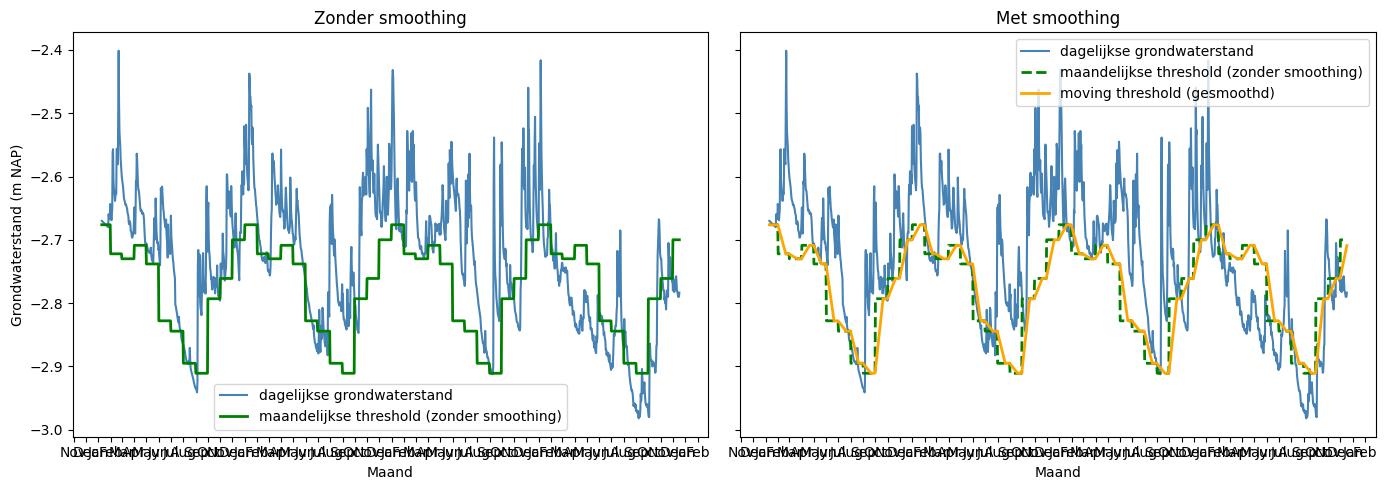

In [55]:
# Zet de twee figuren naast elkaar met een pijl ertussen: links zonder smoothing, rechts met smoothing, met alleen maanden op de x-as
import matplotlib.dates as mdates
import calendar

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Links: zonder smoothing
ax = axes[0]
ax.plot(ts_daily.index, ts_daily, color="steelblue", linewidth=1.5, label="dagelijkse grondwaterstand")
monthly_threshold_full = ts_daily.index.to_series().map(lambda d: monthly_threshold.loc[d.month])
ax.plot(ts_daily.index, monthly_threshold_full, color="green", linewidth=2, label="maandelijkse threshold (zonder smoothing)")
ax.set_title("Zonder smoothing")
ax.set_xlabel("Maand")
ax.set_ylabel("Grondwaterstand (m NAP)")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Rechts: met smoothing
ax = axes[1]
ax.plot(ts_daily.index, ts_daily, color="steelblue", linewidth=1.5, label="dagelijkse grondwaterstand")
ax.plot(ts_daily.index, monthly_threshold_full, color="green", linewidth=2, linestyle="--", label="maandelijkse threshold (zonder smoothing)")
if threshold_variable_smooth is not None:
    ax.plot(threshold_variable_smooth.index, threshold_variable_smooth.values, color="orange", linewidth=2, label="moving threshold (gesmoothd)")
ax.set_title("Met smoothing")
ax.set_xlabel("Maand")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [56]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)

def find_drought_events_with_duration(is_drought, threshold, ts_daily):
    drought_events = []
    in_event = False
    start_date = None
    for date, drought in is_drought.items():
        if drought and not in_event:
            in_event = True
            start_date = date
        elif not drought and in_event:
            end_date = date - pd.Timedelta(days=1)
            deficit = (threshold.loc[start_date:end_date] - ts_daily.loc[start_date:end_date]).max()
            duration = (end_date - start_date).days + 1
            drought_events.append({
                'start': start_date,
                'end': end_date,
                'days': duration,
                'max_deficit': deficit
            })
            in_event = False
    # Handle event ending at last date
    if in_event:
        end_date = is_drought.index[-1]
        deficit = (threshold.loc[start_date:end_date] - ts_daily.loc[start_date:end_date]).max()
        duration = (end_date - start_date).days + 1
        drought_events.append({
            'start': start_date,
            'end': end_date,
            'days': duration,
            'max_deficit': deficit
        })
    return pd.DataFrame(drought_events)

# Fixed threshold drought events
fixed_events = find_drought_events_with_duration(is_drought_fixed, pd.Series(threshold_fixed, index=ts_daily.index), ts_daily)
print("Fixed threshold drought events:")
print(fixed_events)

# Variable threshold drought events (if available)
if threshold_variable_smooth is not None and is_drought_variable is not None:
    var_events = find_drought_events_with_duration(is_drought_variable, threshold_variable_smooth, ts_daily)
    print("Variable threshold drought events:")
    print(var_events)
else:
    print("No variable threshold drought events available.")

# =========================
# TIMELINE SEGMENTS TABLES (NO DEFICIT, ONLY DATES AND CATEGORY)
# =========================
def timeline_segments_table(segments):
    return segments[['start', 'end', 'category']].reset_index(drop=True)

print("Timeline segments (Fixed GW + Fixed NDVI):")
print(timeline_segments_table(segments_fixed))

print("Timeline segments (Variable GW + Fixed NDVI):")
print(timeline_segments_table(segments_var))

Fixed threshold drought events:
        start        end  days  max_deficit
0  2022-07-12 2022-09-05    56     0.151000
1  2022-09-12 2022-09-15     4     0.029000
2  2022-10-29 2022-10-31     3     0.006000
3  2023-06-06 2023-07-26    51     0.092333
4  2023-07-28 2023-07-30     3     0.031167
5  2023-08-21 2023-08-30    10     0.022833
6  2023-09-01 2023-09-01     1     0.003833
7  2023-09-03 2023-09-12    10     0.051667
8  2023-09-14 2023-09-20     7     0.046500
9  2023-10-01 2023-10-12    12     0.057000
10 2024-08-03 2024-09-10    39     0.122333
11 2024-09-18 2024-09-25     8     0.038333
12 2024-10-21 2024-10-21     1     0.003333
13 2024-10-29 2024-11-16    19     0.053333
14 2025-03-18 2025-04-23    37     0.058417
15 2025-04-29 2025-05-01     3     0.008500
16 2025-05-03 2025-05-27    25     0.088900
17 2025-05-29 2025-07-15    48     0.115500
18 2025-07-25 2025-10-22    90     0.192000
19 2025-11-10 2025-11-10     1     0.005000
20 2025-11-12 2025-11-14     3     0.020000
